<a href="https://colab.research.google.com/github/Arshadfarazusmani/Agro-tech/blob/main/Soil_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Downloading data set



In [ ]:
import os
import kagglehub
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rahuljaiswalonkaggle/soil-fertility-dataset")

print("Path to dataset files:", path)

100%|██████████| 16.9k/16.9k [00:00<00:00, 24.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rahuljaiswalonkaggle/soil-fertility-dataset/versions/1


In [ ]:
import pandas as pd
import os

# Construct the full path to the dataset.csv file
dataset_file_path = os.path.join(path, 'dataset1.csv') # Changed 'dataset.csv' to 'dataset1.csv'

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(dataset_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())
# display(df.foot())


,N,P,K,pH,EC,OC,S,Zn,Fe,Cu,Mn,B,Output
0,138,8.6,560,7.46,0.62,0.70,5.9,0.24,0.31,0.77,8.71,0.11,0
1,213,7.5,338,7.62,0.75,1.06,25.4,0.30,0.86,1.54,2.89,2.29,0
2,163,9.6,718,7.59,0.51,1.11,14.3,0.30,0.86,1.57,2.70,2.03,0
3,157,6.8,475,7.64,0.58,0.94,26.0,0.34,0.54,1.53,2.65,1.82,0
4,270,9.9,444,7.63,0.40,0.86,11.8,0.25,0.76,1.69,2.43,2.26,1


In [ ]:
import os

# List the contents of the downloaded dataset directory
print(os.listdir(path))

['dataset1.csv']


In [ ]:
!pip install imbalanced-learn

In [ ]:
import os

dataset_file_path = os.path.join(path, 'dataset1.csv')
df = pd.read_csv(dataset_file_path)
df.head()
print(df.columns)

Index(['N', 'P', 'K', 'pH', 'EC', 'OC', 'S', 'Zn', 'Fe', 'Cu', 'Mn', 'B',
       'Output'],
      dtype='object')


In [ ]:
X = df.drop("Output", axis=1)
y = df["Output"]

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
from collections import Counter
print("Before:", Counter(y))
print("After:", Counter(y_resampled))

Before: Counter({1: 440, 0: 401, 2: 39})
After: Counter({0: 440, 1: 440, 2: 440})


In [ ]:
balanced_df = pd.concat(
    [pd.DataFrame(X_resampled), pd.DataFrame(y_resampled, columns=["Output"])],
    axis=1
)

In [ ]:
balanced_df.to_csv("balanced_soil_dataset.csv", index=False)

In [ ]:
balanced_df.to_csv("balanced_soil_dataset.csv", index=False)

In [ ]:
from google.colab import files
files.download("balanced_soil_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_csv("balanced_soil_dataset.csv")

X = df.drop("Output", axis=1)
y = df["Output"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# logistic Regression

In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7462121212121212
              precision    recall  f1-score   support

           0       0.87      0.88      0.87        88
           1       0.65      0.66      0.66        88
           2       0.72      0.70      0.71        88

    accuracy                           0.75       264
   macro avg       0.75      0.75      0.75       264
weighted avg       0.75      0.75      0.75       264



# Random forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.928030303030303
              precision    recall  f1-score   support

           0       0.88      0.95      0.92        88
           1       0.93      0.90      0.91        88
           2       0.98      0.93      0.95        88

    accuracy                           0.93       264
   macro avg       0.93      0.93      0.93       264
weighted avg       0.93      0.93      0.93       264



# confusion metrics

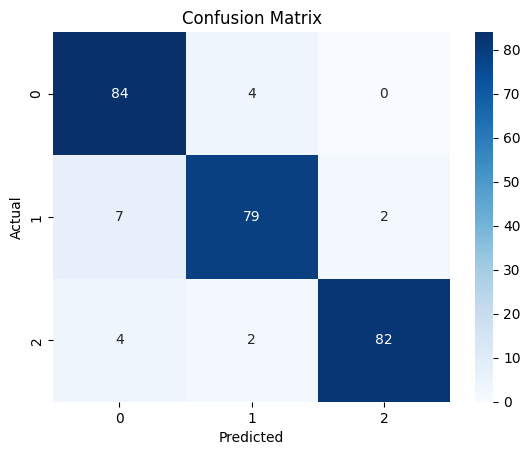

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# feature importance

In [ ]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

   Feature  Importance
0        N    0.395235
1        P    0.237172
10      Mn    0.046242
3       pH    0.046026
9       Cu    0.043928
11       B    0.041649
5       OC    0.036749
8       Fe    0.034426
4       EC    0.033133
2        K    0.029171
6        S    0.029136
7       Zn    0.027133


In [ ]:
import joblib

joblib.dump(rf_model, "soil_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from google.colab import files

files.download("soil_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## validation

In [ ]:
import joblib
import pandas as pd

# Load the saved model and scaler
loaded_model = joblib.load('soil_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Create a sample data point for prediction (ensure it has the same columns as X)
# For demonstration, let's take the first row of X_test as a sample
sample_data = X_test.iloc[0].values.reshape(1, -1)

# Scale the sample data using the loaded scaler
sample_scaled = loaded_scaler.transform(sample_data)

# Make a prediction
prediction = loaded_model.predict(sample_scaled)

print(f"Sample data for prediction (original):\n{X_test.iloc[0]}")
print(f"Predicted class for the sample: {prediction[0]}")
print(f"Actual class for the sample: {y_test.iloc[0]}")

Sample data for prediction (original):
N     377.000000
P      11.489057
K     632.000000
pH      7.800000
EC      0.616256
OC      0.548259
S       4.140674
Zn      0.370000
Fe      0.857288
Cu      0.300709
Mn      1.251817
B       0.897488
Name: 1318, dtype: float64
Predicted class for the sample: 0
Actual class for the sample: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.81818182 0.93560606 0.91666667 0.86363636 0.85227273]
Average CV Score: 0.8772727272727273


In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7462121212121212


In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.928030303030303


These lines directly compute and display the accuracy score using `sklearn.metrics.accuracy_score` by comparing the actual test labels (`y_test`) with the model's predicted labels (`y_pred_log` or `y_pred_rf`). For a more in-depth understanding of accuracy and other evaluation metrics like precision, recall, F1-score, confusion matrix, and cross-validation, please refer to the previous explanation of 'how to evaluate model'.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


After mounting, I will copy the `soil_model.pkl` and `scaler.pkl` files to a folder named 'soil_fertility_models' within your 'Colab Notebooks' directory in Google Drive. If the folder doesn't exist, it will be created.

In [ ]:
import os
import shutil

drive_path = '/content/drive/MyDrive/Colab Notebooks/soil_fertility_models'
os.makedirs(drive_path, exist_ok=True)

shutil.copy('soil_model.pkl', os.path.join(drive_path, 'soil_model.pkl'))
shutil.copy('scaler.pkl', os.path.join(drive_path, 'scaler.pkl'))

print(f"'soil_model.pkl' and 'scaler.pkl' saved to {drive_path}")

'soil_model.pkl' and 'scaler.pkl' saved to /content/drive/MyDrive/Colab Notebooks/soil_fertility_models
